### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
 

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [27]:
data = pd.read_csv('data/coupons.csv')

In [28]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [29]:
entries = ''
no_coupon_info = ''
data_null_values = ''
coupon_types = ''

#First we'll evaluate how many rows/entries are in the data (12684)
entries = len(data)
print(entries)

#Then we will look at all the column names
print(data.columns.tolist())

#We will go through the columns to identify null values
data_null_values = data.isnull().sum()
print(data_null_values)

#We will look to see if there are any unusual coupon entries or rare entries

coupon_types = data.groupby('coupon')['coupon'].count()
print(coupon_types)

#Going to look at what the car line is to figure out what to do with most of the values being empty
car_types = data.groupby('car')['car'].count()
print(car_types)

#looking at the cheap restuarant values
car_types = data.groupby('RestaurantLessThan20')['RestaurantLessThan20'].count()
print(car_types)

#looking at the income values
car_types = data.groupby('income')['income'].count()
print(car_types)

12684
['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
to

3. Decide what to do about your missing data -- drop, replace, other...

In [30]:
#For the car data, I'm going to drop values that are "do not drive" and "scooter and motorcycle" to limit 
#results to people who are driving a car; limiting the scope will help account for things like needing to park.
#I'm keeping the "car that is too old to install Onstar" since it is not mentioned that Onstar is required for the application
drop_values = ['Scooter and motorcycle', 'do not drive']
data_cleaned = data[data.car.isin(drop_values) == False]

#looking at the current length of data
entries_cleaned = len(data_cleaned)
print(entries_cleaned)

#Checking that values were dropped
car_types_cleaned = data_cleaned.groupby('car')['car'].count()
print(car_types_cleaned)

12640
car
Car that is too old to install Onstar :D    21
Mazda5                                      22
crossover                                   21
Name: car, dtype: int64


4. What proportion of the total observations chose to accept the coupon?



0.56875


Text(0.5, 1.0, 'Accepted coupouns?')

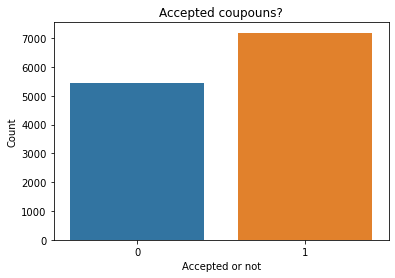

In [31]:
#Counting the number of entries with 1 in the Y column and deviding by the total number of entries in the cleaned data
Proportion_accepted = (data_cleaned['Y'] ==1).sum()/entries_cleaned
print(Proportion_accepted)

#Checking with a bar graph of Y column to see if makes sense
sns.barplot(data = data_cleaned, x = data_cleaned['Y'].value_counts().index, y = data_cleaned['Y'].value_counts().values)
plt.ylabel('Count')
plt.xlabel('Accepted or not')
plt.title('Accepted coupouns?')

5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Coupon Location')

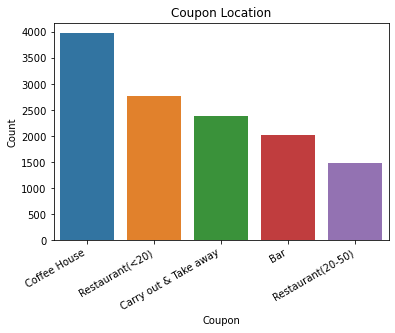

In [32]:
#Generating the plot
sns.barplot(data = data_cleaned, x = data_cleaned['coupon'].value_counts().index, y = data_cleaned['coupon'].value_counts().values)
plt.xticks(rotation = 30, ha = 'right')
#Adding labels and title
plt.ylabel('Count')
plt.xlabel('Coupon')
plt.title('Coupon Location')


6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Temperature Distribution')

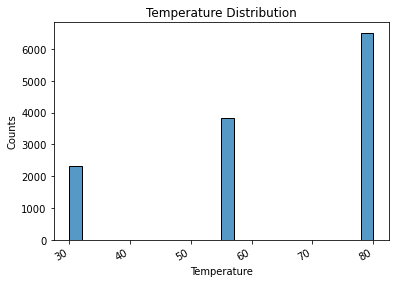

In [33]:
#Generating the plot
sns.histplot(data = data_cleaned, x = 'temperature')
#Adding labels and title
plt.xticks(rotation = 30, ha = 'right')
plt.ylabel('Counts')
plt.xlabel('Temperature')
plt.title('Temperature Distribution')


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [34]:
#Pulling out rows where the coupon column has the value Bar
bar_data = data_cleaned[data_cleaned['coupon'] == 'Bar']

#checking new dataframe to make sure it makes sense
#Printing the values and count to make sure it's only coupon = Bar
print(bar_data['coupon'].value_counts())


Bar    2012
Name: coupon, dtype: int64


2. What proportion of bar coupons were accepted?


0.4095427435387674


Text(0.5, 1.0, 'Bar coupon accepted coupouns?')

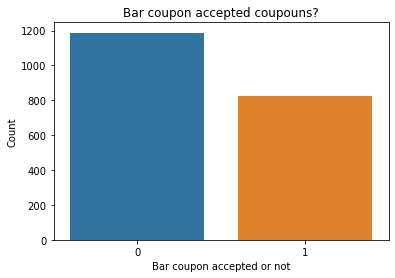

In [35]:
#Counting the number of entries in the bar data with 1 in the Y column and deviding by the total number of entries in the bar data
Bar_proportion_accepted = (bar_data['Y'] ==1).sum()/len(bar_data)
print(Bar_proportion_accepted)

#Including a bar graph to check that the proportion seems right
sns.barplot(data = bar_data, x = bar_data['Y'].value_counts().index, y = bar_data['Y'].value_counts().values)
plt.ylabel('Count')
plt.xlabel('Bar coupon accepted or not')
plt.title('Bar coupon accepted coupouns?')

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [36]:
#Starting by making sure the Bar column contains this information and what the values look like
bar_types = bar_data.groupby('Bar')['Bar'].count().sort_values()

#Finding the number accepted for bar visits greater than 3 (4~8 and gt8)
acceptance_bar_greater_3 = (bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]['Y'] == 1).sum()

#Finding the number accepted for entries with bar visits less than for equal to3 a month (1~3, less1, never)
acceptance_bar_less_or_equal_3 = (bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])]['Y'] == 1).sum()

#Finding the total number accepted for bar visits greater than 3 (4~8 and gt8)
total_bar_greater_3 = len(bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])])

#Finding the total number accepted for bar visits less than or equal to 3 times a month (4~8 and gt8)
total_bar_less_or_equal_3 = len(bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])])

#Finding the proportions of accepted to rejected for each group
proportion_bar_greater_3 = acceptance_bar_greater_3/total_bar_greater_3
print('Proportion accepted who go to bar less than or = 3 times a month: ' + str(proportion_bar_greater_3))

proportion_bar_less_or_equal = acceptance_bar_less_or_equal_3/total_bar_less_or_equal_3
print('Proportion accepted greater than 3 times a month: ' + str(proportion_bar_less_or_equal))


Proportion accepted who go to bar less than or = 3 times a month: 0.766497461928934
Proportion accepted greater than 3 times a month: 0.37068004459308806


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [37]:

#Going to strip the non-numerical values in this code, so 50plus will be 50 and below21 will be 21. Then I will make them integers
bar_data['age'] = pd.to_numeric(bar_data['age'].str.replace(r'[^0-9]', '', regex=True), errors='coerce')



/var/folders/4k/3xpsmv957797_f1x2jsyzxzc0000gp/T/ipykernel_29897/1455250100.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_data['age'] = pd.to_numeric(bar_data['age'].str.replace(r'[^0-9]', '', regex=True), errors='coerce')


In [38]:
#starting a new cell so don't have to rerun the str replace to test the code


#making a mask to split the dataframe by
mask_over25_barover1 = (bar_data['age'] > 25) & (bar_data['Bar'].isin(['1~3','4~8', 'gt8']))

#Making two dataframes one of everyone over 25 who visit a bar more than 1 time a month the other with everyone else
bar_1month_and_over25 = bar_data[mask_over25_barover1]
rest_of_bar_data = bar_data[~mask_over25_barover1]


#Calculating the acceptance rates and printing the values for comparison
target_rate1 = (bar_1month_and_over25['Y']).mean()
others_rate1 = (rest_of_bar_data['Y']).mean()



print(f"Proportion accepted when bar > 1/month & age > 25): {target_rate1:}")
print(f"Proportion accepted all others:                {others_rate1:}")

Proportion accepted when bar > 1/month & age > 25): 0.69377990430622
Proportion accepted all others:                0.33500627352572143


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [39]:
#Creating a mask to split the list
mask_barOver1_noKids = (bar_data['Bar'].isin(['1~3','4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['occupation'] != 'Farming Fishing & Forestry')

#Splitting based on qualifies
bar_over1_nokids = bar_data[mask_barOver1_noKids]
rest_of_bar_kid_data = bar_data[~mask_barOver1_noKids]




target_rate2 = (bar_over1_nokids['Y']).mean()
others_rate2 = (rest_of_bar_kid_data['Y']).mean()

print(f"Proportion accepted when bar > 1/month & No kids as passengers & occupation not in Farming Fishing & Forestry): {target_rate2:}")
print(f"Proportion accepted all others:                {others_rate2:}")

Proportion accepted when bar > 1/month & No kids as passengers & occupation not in Farming Fishing & Forestry): 0.7122040072859745
Proportion accepted all others:                0.2959671907040328


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [40]:
#Creating a masks to split the list by the catagories listed
mask_barOver1_noKids_notwidowed = (bar_data['Bar'].isin(['1~3','4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['passanger'] != 'Alone') & (bar_data['maritalStatus'] != 'widowned') 
mask_barOver1_over30 = (bar_data['age'] < 30) & (bar_data['Bar'].isin(['1~3','4~8', 'gt8']))
mask_cheapRestove4_incomeunder50K = (bar_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])) & (bar_data['income'].isin(['$12500 - $24999', '$25000 - $37499','$37500 - $49999']))


#Creating the three different ratios
over30_barOver1_nowidow_ratio = bar_data[mask_barOver1_noKids_notwidowed]['Y'].mean()
barover1_over30_ratio = bar_data[mask_barOver1_over30]['Y'].mean()
cheapRestove4_incomeunder50K_ratio = bar_data[mask_cheapRestove4_incomeunder50K]['Y'].mean()


print(f"Proportion accepted when under 30 & No kids as passengers & not widowed): {over30_barOver1_nowidow_ratio:}")
print(f"Proportion that go to bar over 1 a month and are over 30:                {barover1_over30_ratio:}")
print(f"Proportion that go to a cheap restaurant over once a month and have income under 50K:                {cheapRestove4_incomeunder50K_ratio:}")

Proportion accepted when under 30 & No kids as passengers & not widowed): 0.7164948453608248
Proportion that go to bar over 1 a month and are over 30:                0.7201166180758017
Proportion that go to a cheap restaurant over once a month and have income under 50K:                0.4575645756457565


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Text(0.5, 1.0, 'Bar coupon accepted coupouns based on bar attendance?')

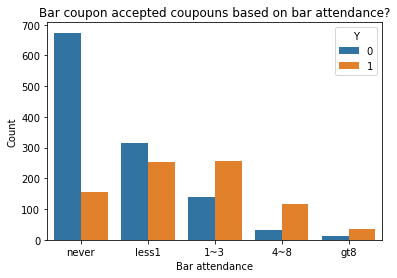

In [41]:
#There appears to be a correlation (potentially a very strong one) between people who go to a bar at least once a month and people who will accept a bar coupon

#Generating the plot to evaluate this guess.
sns.countplot(data=bar_data, x='Bar', hue='Y', order=bar_data['Bar'].value_counts().index)
plt.ylabel('Count')
plt.xlabel('Bar attendance')
plt.title('Bar coupon accepted coupouns based on bar attendance?')


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Proportion of take away coupons accepted): 0.7359597652975691


Text(0.5, 1.0, 'Take away coupon accepted coupouns?')

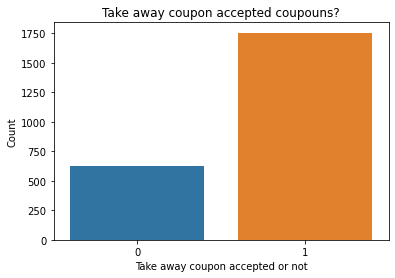

In [42]:
#Going to look at the take away coupon catagory
#creating data table where the coupon type is Carry out & Take Away
data_cleaned['coupon'].value_counts()
takeaway_data = data_cleaned[data_cleaned['coupon'] == 'Carry out & Take away']

#Calculating the proportion of Carry away coupons accepted
TakeAway_proportion_accepted = (takeaway_data['Y'] ==1).sum()/len(takeaway_data)
print(f"Proportion of take away coupons accepted): {TakeAway_proportion_accepted:}")

#Including a bar graph to check that the proportion seems right
sns.barplot(data = takeaway_data, x = takeaway_data['Y'].value_counts().index, y = takeaway_data['Y'].value_counts().values)
plt.ylabel('Count')
plt.xlabel('Take away coupon accepted or not')
plt.title('Take away coupon accepted coupouns?')


Acceptance Rates by CarryAway Frequency:
Y            0    1  acceptance_rate
CarryAway                           
1~3        227  633            73.60
4~8        200  617            75.52
gt8         79  223            73.84
less1      113  240            67.99
never        8   24            75.00
Chi-Square Test:
  Chi2 Statistic : 7.2721
  Degrees of Freedom: 4
  P-Value        : 0.1222
  Significant    : No, the probabilities are not statistically distinct


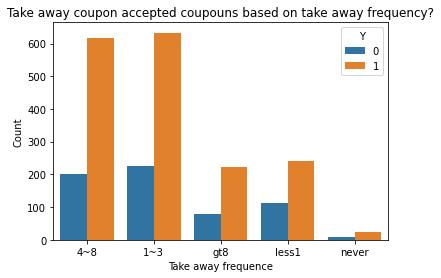

In [43]:
#Plotting Take away based on Carry away order frequency
sns.countplot(data=takeaway_data, x='CarryAway', hue='Y')
plt.ylabel('Count')
plt.xlabel('Take away frequence')
plt.title('Take away coupon accepted coupouns based on take away frequency?')
#Saving the plot
plt.savefig('coupon_takeaway_barplot.png', dpi = 300)

#Making a contigency table with rates included to compare the rates of acceptance based on Carry away frequency

contingency_table = pd.crosstab(takeaway_data['CarryAway'], takeaway_data['Y'])

contingency_table['acceptance_rate'] = (
    contingency_table[1] / contingency_table.sum(axis=1) * 100
).round(2)
print("Acceptance Rates by CarryAway Frequency:")
print(contingency_table)

# Using a Chi-squared test to see  whether coupon acceptance is independent of Carry Away frequency
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table[[0, 1]]  # exclude the acceptance_rate column
)
print(f"Chi-Square Test:")
print(f"  Chi2 Statistic : {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value        : {p_value:.4f}")
print(f"  Significant    : {'Yes, the populations are statistically distinct' if p_value < 0.05 else 'No, the probabilities are not statistically distinct'}")

In [44]:
#Based on the plot above I am going to look at the ratios of accepting by people who do take out at least once a month to those less than once a month
#creating a mask to seperate the data
mask_take_away_greater_1 = (takeaway_data['CarryAway'].isin(['1~3','4~8', 'gt8']))

#Seperating the data and calculating the proportion that accept
take_away_greater_1 = takeaway_data[mask_take_away_greater_1]['Y'].mean()
take_away_less_1 = takeaway_data[~mask_take_away_greater_1]['Y'].mean()

print(f"Proportion accepted when have take away at least once a week): {take_away_greater_1:}")
print(f"Proportion accepted when have take away less than once a week): {take_away_less_1:}")

#Running a t-test to see if the populations of carry away frequency seperated by 1 are distinct
t_stat, p_value = stats.ttest_ind(takeaway_data[mask_take_away_greater_1]['Y'], takeaway_data[~mask_take_away_greater_1]['Y'])

print(f"\nTwo-Sample T-Test:")
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.4f}")
print(f"  Significant : {'Yes' if p_value < 0.05 else 'No'}")


Proportion accepted when have take away at least once a week): 0.7443153107630116
Proportion accepted when have take away less than once a week): 0.6953316953316954

Two-Sample T-Test:
  T-Statistic : 2.0425
  P-Value     : 0.0412
  Significant : Yes


Acceptance Rates by CarryAway Frequency:
Y            0     1  acceptance_rate
passanger                            
Alone      382  1021            72.77
Friend(s)  177   557            75.89
Kid(s)      45   107            70.39
Partner     26    71            73.20
Chi-Square Test:
  Chi2 Statistic : 3.2791
  Degrees of Freedom: 3
  P-Value        : 0.3506
  Significant    : No, the probabilities are not statistically distinct


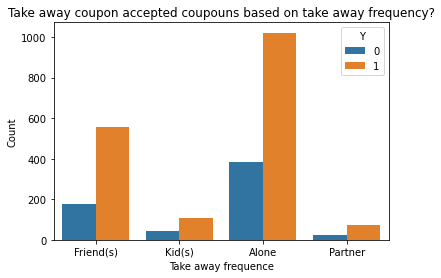

In [45]:
#Generating a plot to look at the frequencies based on whether or not there are passengers
sns.countplot(data=takeaway_data, x='passanger', hue='Y')
plt.ylabel('Count')
plt.xlabel('Take away frequence')
plt.title('Take away coupon accepted coupouns based on take away frequency?')

#Making contigency table with acceptance rate added to it
contingency_table = pd.crosstab(takeaway_data['passanger'], takeaway_data['Y'])

contingency_table['acceptance_rate'] = (
    contingency_table[1] / contingency_table.sum(axis=1) * 100
).round(2)
print("Acceptance Rates by CarryAway Frequency:")
print(contingency_table)

# Tests whether coupon acceptance is independent of passanger status using chi-squared test
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table[[0, 1]]  # exclude the acceptance_rate column
)
print(f"Chi-Square Test:")
print(f"  Chi2 Statistic : {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value        : {p_value:.4f}")
print(f"  Significant    : {'Yes, the populations are statistically distinct' if p_value < 0.05 else 'No, the probabilities are not statistically distinct'}")



Acceptance Rates by CarryAway Frequency:
Y          0    1  acceptance_rate
age                               
21       126  360            74.07
26       123  340            73.43
31       116  278            70.56
36        63  186            74.70
41        59  150            71.77
46        34   91            72.80
50plus    78  268            77.46
below21   31   83            72.81
Chi-Square Test:
  Chi2 Statistic : 5.1797
  Degrees of Freedom: 7
  P-Value        : 0.6380
  Significant    : No, the probabilities are not statistically distinct


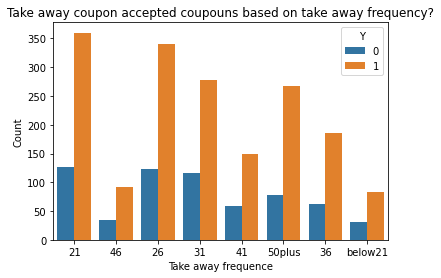

In [46]:
#graphing the frequency of acceptance based on age to see if there is anything dramatic

sns.countplot(data=takeaway_data, x='age', hue='Y')
plt.ylabel('Count')
plt.xlabel('Take away frequence')
plt.title('Take away coupon accepted coupouns based on take away frequency?')

#Making contigency table with acceptance rate added to it

contingency_table = pd.crosstab(takeaway_data['age'], takeaway_data['Y'])

contingency_table['acceptance_rate'] = (
    contingency_table[1] / contingency_table.sum(axis=1) * 100
).round(2)
print("Acceptance Rates by CarryAway Frequency:")
print(contingency_table)


# Tests whether coupon acceptance is independent of age  using chi-squared test
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table[[0, 1]]  # exclude the acceptance_rate column
)
print(f"Chi-Square Test:")
print(f"  Chi2 Statistic : {chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  P-Value        : {p_value:.4f}")
print(f"  Significant    : {'Yes, the populations are statistically distinct' if p_value < 0.05 else 'No, the probabilities are not statistically distinct'}")



Text(0.5, 1.0, 'Take away coupon accepted coupouns based on  direction?')

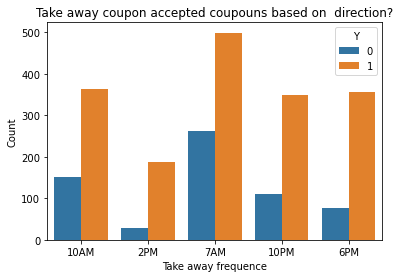

In [48]:
#graphing the frequency of acceptance based on time of day to see if there is anything dramatic

sns.countplot(data=takeaway_data, x='time', hue='Y')
plt.ylabel('Count')
plt.xlabel('Take away frequence')
plt.title('Take away coupon accepted coupouns based on  direction?')



Text(0.5, 1.0, 'Take away coupon accepted coupouns based on  direction?')

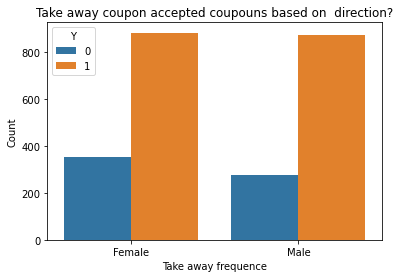

In [49]:
#graphing the frequency of acceptance based on gender to see if there is anything dramatic
sns.countplot(data=takeaway_data, x='gender', hue='Y')
plt.ylabel('Count')
plt.xlabel('Take away frequence')
plt.title('Take away coupon accepted coupouns based on  direction?')



In [50]:
#Conclusions on acceptance of a coupon for take away
#Take away coupons are very popular accross populations, there is generally very little difference
#determained by the data that was collected here (although techinically it was statistically 
#shown that people who order take out more than once a week are slightly more likely to use the coupon